# ДЗ 5. Класифікація природних сцен (Intel Image Classification)


In [1]:
import os, sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(device)

mps


## Дані

In [2]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    zip_path = "/content/drive/MyDrive/intel_image_classification.zip"  # шлях до архіву на своєму Drive
    if not Path("/content/data").exists():
        os.system(f'unzip -q "{zip_path}" -d /content/data')
    DATA_ROOT = Path("/content/data")
else:
    DATA_ROOT = Path(".")

def find_class_root(root, name):
    # у датасеті папки продубльовані (seg_train/seg_train), шукаю ту, всередині якої лежать класи
    for p in sorted(root.rglob(name)):
        if (p / "forest").is_dir():
            return p
    raise FileNotFoundError(name)

TRAIN_DIR = find_class_root(DATA_ROOT, "seg_train")
TEST_DIR = find_class_root(DATA_ROOT, "seg_test")
print(TRAIN_DIR)
print(TEST_DIR)

seg_train/seg_train
seg_test/seg_test


## Трансформації і завантажувачі

Нормалізація зі статистиками ImageNet, бо саме на них навчена ResNet18. Для train додаю легку
аугментацію (фліп, поворот, jitter кольору), для валідації і тесту тільки resize і нормалізація.
Тому створюю два об'єкти ImageFolder на train папку з різними transform і ділю їх за спільними
індексами, стратифіковано за класами (15% на валідацію).

In [3]:
IMG_SIZE = 150
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_full_aug = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
train_full_plain = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)

classes = train_full_aug.classes
targets = train_full_aug.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.15, stratify=targets, random_state=SEED)

train_ds = Subset(train_full_aug, train_idx)
val_ds = Subset(train_full_plain, val_idx)

print(classes)
print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train: 11928, val: 2106, test: 3000


In [4]:
batch_size = 64
num_workers = 2
pin = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=pin)

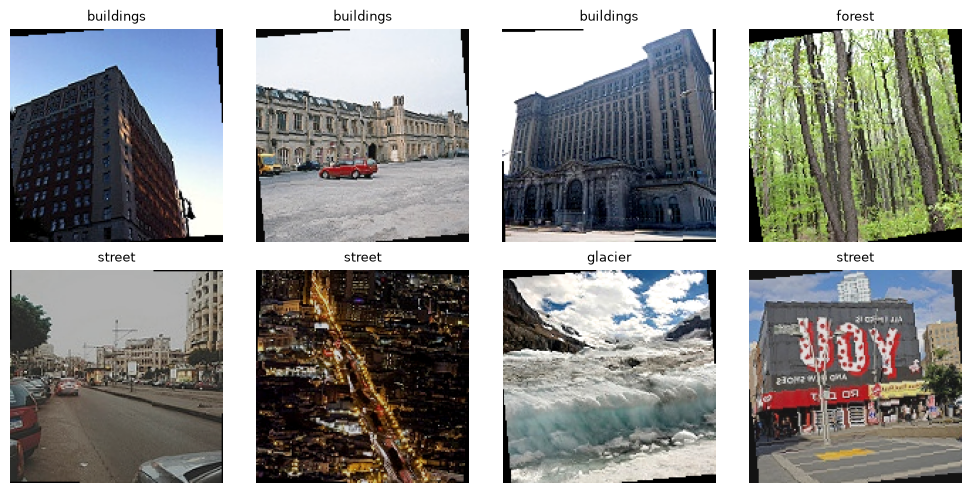

In [5]:
def denorm(x):
    return (x * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)).clamp(0, 1)

X, y = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lbl in zip(axes.flat, X, y):
    ax.imshow(denorm(img).permute(1, 2, 0))
    ax.set_title(classes[lbl], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Варіант A. Проста CNN

4 згорткових блоки (Conv 3x3 + BatchNorm + ReLU + MaxPool), після них два повнозв'язні шари.
Кожен блок вдвічі зменшує просторовий розмір і нарощує кількість каналів: 150 -> 75 -> 37 -> 18 -> 9.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn = SimpleCNN(len(classes)).to(device)
print(sum(p.numel() for p in cnn.parameters()) / 1e6, "M параметрів")

5.69959 M параметрів


## Функція втрат і оптимізатор

CrossEntropyLoss: стандартний вибір для багатокласової класифікації з одним правильним класом.
Це softmax + негативний log-likelihood, сильно штрафує впевнені помилкові передбачення.

Оптимізатор Adam: адаптивний крок для кожного параметра, збігається швидко без ручного підбору
розкладу learning rate, що зручно для коротких навчань.

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n


def fit(model, name, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        (p for p in model.parameters() if p.requires_grad), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc = 0.0
    for epoch in range(1, epochs + 1):
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion)
        for k, v in zip(hist, (tl, vl, ta, va)):
            hist[k].append(v)
        mark = ""
        if va > best_acc:  # зберігаю ваги з найкращою валідаційною точністю
            best_acc = va
            torch.save(model.state_dict(), f"best_{name}.pt")
            mark = " *"
        print(f"epoch {epoch:2d} | train loss {tl:.4f} acc {ta:.4f} | "
              f"val loss {vl:.4f} acc {va:.4f}{mark}")
    return hist

In [8]:
hist_cnn = fit(cnn, "simple_cnn", epochs=6, lr=1e-3)

epoch  1 | train loss 1.4328 acc 0.5338 | val loss 0.8545 acc 0.6747 *


epoch  2 | train loss 0.8648 acc 0.6793 | val loss 0.6573 acc 0.7716 *


epoch  3 | train loss 0.7523 acc 0.7288 | val loss 0.5522 acc 0.8086 *


epoch  4 | train loss 0.6672 acc 0.7594 | val loss 0.5800 acc 0.7901


epoch  5 | train loss 0.6419 acc 0.7686 | val loss 0.5286 acc 0.8172 *


epoch  6 | train loss 0.6189 acc 0.7806 | val loss 0.7061 acc 0.7483


## Варіант B. Transfer learning, ResNet18

Беру ResNet18 з вагами ImageNet. Ранні шари виділяють універсальні ознаки (краї, текстури),
тому їх заморожую, а донавчаю тільки останній блок layer4 і новий вихідний шар на 6 класів.
Це менше параметрів для оновлення.

In [9]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in resnet.parameters():
    p.requires_grad = False
for p in resnet.layer4.parameters():
    p.requires_grad = True
resnet.fc = nn.Linear(resnet.fc.in_features, len(classes))
resnet = resnet.to(device)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(trainable / 1e6, "M навчаних параметрів")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/andyparshyn/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]


  2%|▏         | 896k/44.7M [00:00<00:05, 9.15MB/s]


  7%|▋         | 3.00M/44.7M [00:00<00:02, 16.5MB/s]


 12%|█▏        | 5.25M/44.7M [00:00<00:02, 19.7MB/s]

...


 86%|████████▋ | 38.6M/44.7M [00:01<00:00, 21.4MB/s]


 91%|█████████ | 40.8M/44.7M [00:01<00:00, 21.5MB/s]


 96%|█████████▌| 42.9M/44.7M [00:02<00:00, 21.5MB/s]


100%|██████████| 44.7M/44.7M [00:02<00:00, 21.5MB/s]

8.396806 M навчаних параметрів


In [10]:
hist_resnet = fit(resnet, "resnet18", epochs=4, lr=3e-4)

epoch  1 | train loss 0.3191 acc 0.8899 | val loss 0.2476 acc 0.9155 *


epoch  2 | train loss 0.1964 acc 0.9295 | val loss 0.2278 acc 0.9221 *


epoch  3 | train loss 0.1502 acc 0.9441 | val loss 0.2942 acc 0.8993


epoch  4 | train loss 0.1274 acc 0.9533 | val loss 0.2259 acc 0.9307 *


## Оцінка на тесті

Основні метрики: accuracy і macro F1. Класи тут майже збалансовані, тому accuracy інформативна,
але macro F1 рахує precision і recall окремо для кожного класу і усереднює з рівною вагою,
тож просідання на одному класі (наприклад, систематична плутанина glacier з mountain) видно
одразу, а не розмивається загальною точністю.

In [11]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    for X, y in loader:
        logits = model(X.to(device))
        ps.append(logits.argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

cnn.load_state_dict(torch.load("best_simple_cnn.pt", map_location=device))
resnet.load_state_dict(torch.load("best_resnet18.pt", map_location=device))

for name, model in [("Проста CNN", cnn), ("ResNet18 TL", resnet)]:
    y_true, y_pred = predict_all(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}: test accuracy = {acc:.4f}, macro F1 = {f1:.4f}")

Проста CNN: test accuracy = 0.8063, macro F1 = 0.8072


ResNet18 TL: test accuracy = 0.9293, macro F1 = 0.9304


In [12]:
y_true, y_pred = predict_all(resnet, test_loader)
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

              precision    recall  f1-score   support

   buildings      0.930     0.918     0.924       437
      forest      0.989     0.989     0.989       474
     glacier      0.893     0.886     0.889       553
    mountain      0.906     0.878     0.892       525
         sea      0.938     0.975     0.956       510
      street      0.927     0.938     0.933       501

    accuracy                          0.929      3000
   macro avg      0.930     0.931     0.930      3000
weighted avg      0.929     0.929     0.929      3000



## Криві навчання

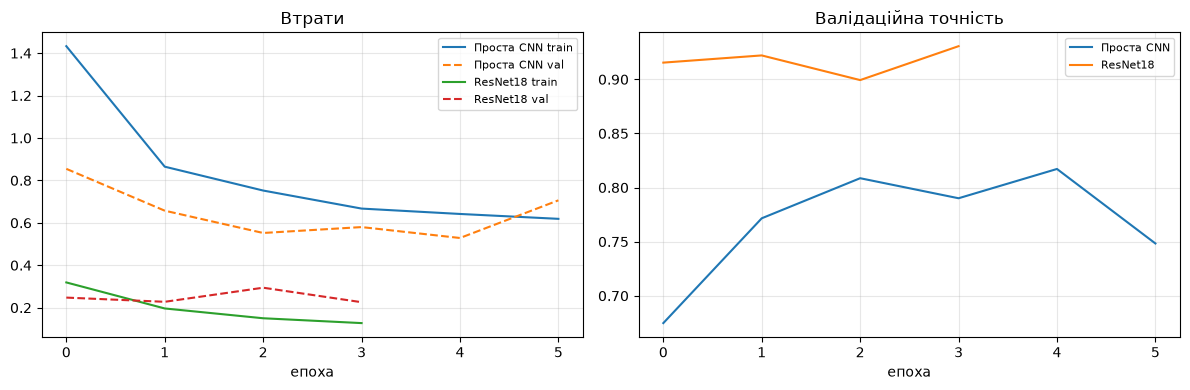

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name in [(hist_cnn, "Проста CNN"), (hist_resnet, "ResNet18")]:
    axes[0].plot(hist["train_loss"], label=f"{name} train")
    axes[0].plot(hist["val_loss"], "--", label=f"{name} val")
    axes[1].plot(hist["val_acc"], label=name)
axes[0].set_title("Втрати")
axes[0].set_xlabel("епоха")
axes[1].set_title("Валідаційна точність")
axes[1].set_xlabel("епоха")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

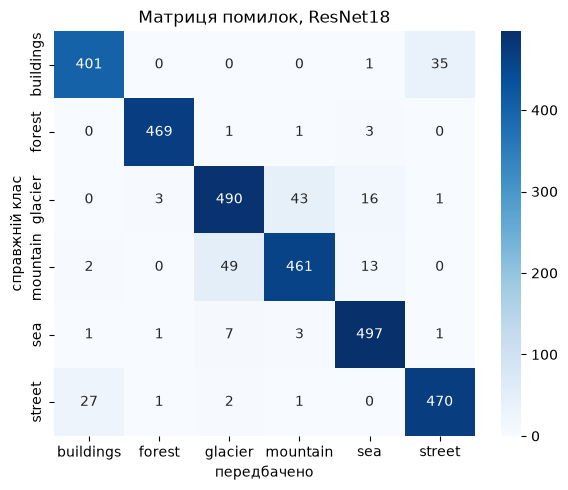

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("передбачено")
plt.ylabel("справжній клас")
plt.title("Матриця помилок, ResNet18")
plt.tight_layout()
plt.show()

## Аналіз помилок

помилок на тесті: 212 з 3000


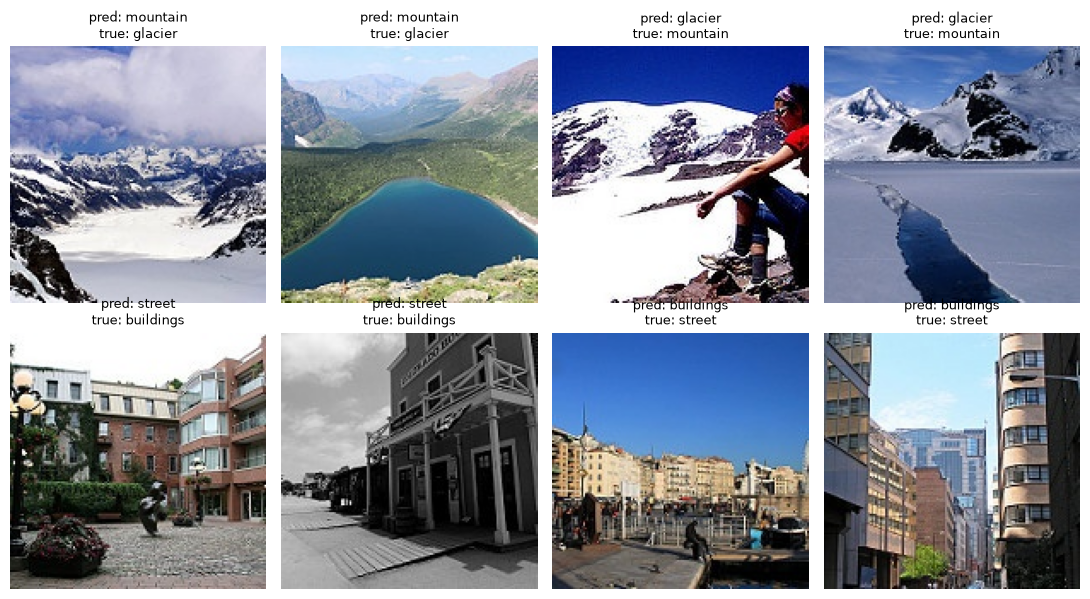

In [15]:
wrong = np.where(y_true != y_pred)[0]
print(f"помилок на тесті: {len(wrong)} з {len(y_true)}")

# по 2 приклади з кожної головної пари плутанини
pairs = [("glacier", "mountain"), ("mountain", "glacier"),
         ("buildings", "street"), ("street", "buildings")]
show = []
for t, p in pairs:
    ti, pi = classes.index(t), classes.index(p)
    show += list(np.where((y_true == ti) & (y_pred == pi))[0][:2])

fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for ax, i in zip(axes.flat, show):
    img, _ = test_ds[i]
    ax.imshow(denorm(img).permute(1, 2, 0))
    ax.set_title(f"pred: {classes[y_pred[i]]}\ntrue: {classes[y_true[i]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Дві головні пари плутанини добре видно і на матриці, і на прикладах вище:

- **glacier <-> mountain** (43 + 49 помилок). Засніжені гори і льодовики часто виглядають однаково:
  сніг, скелі, небо. Частину таких картинок і людина розвела б не одразу. Ще glacier і mountain
  іноді ідуть у sea, коли в кадрі багато води або блакитного льоду.
- **buildings <-> street** (35 + 27 помилок). На прикладах помилок видно, що майже всі "buildings",
  передбачені як "street", реально зняті з вулиці і містять і будівлі, і дорогу. Це швидше шум
  розмітки, ніж слабкість моделі: класи перекриваються за змістом.

Forest і sea розпізнаються майже ідеально (F1 0.99 і 0.96), у них найвиразніша текстура і колір.

## Висновки і можливі покращення

Transfer learning очікувано виграв: ResNet18 дав test accuracy 0.929 і macro F1 0.930 проти
0.806 / 0.807 у простої CNN, при цьому навчався 4 епохи проти 6. Ознаки, вивчені на ImageNet,
добре переносяться на природні сцени, донавчати довелось тільки layer4 і новий вихідний шар.